In [25]:
import os

def find_file_by_ext(folder_path, extensions):
    """
    Returns the first file in folder_path matching any extension in extensions
    """
    for f in os.listdir(folder_path):
        if f.lower().endswith(extensions):
            return os.path.join(folder_path, f)
    return None


In [26]:
def find_all_images(folder_path):
    return sorted([
        os.path.join(folder_path, f)
        for f in os.listdir(folder_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])


In [27]:
import json, gzip, lzma

def load_metadata(path):
    if path.endswith(".gz"):
        with gzip.open(path, "rt", encoding="utf-8") as f:
            return json.load(f)
    elif path.endswith(".xz"):
        with lzma.open(path, "rt", encoding="utf-8") as f:
            return json.load(f)

meta_path = r".\datasets\Data\aashnashroff_969148_3000403601659402518_25980_65\2022-12-24_15-33-23_UTC.json.xz"
meta = load_metadata(meta_path)
print(meta.keys())
print(meta['node'].keys())
for k, v in meta['node'].items():
    print("KEY:", k)
    print("VALUE:", v)
    print("-" * 40)
# import pprint
# pprint.pprint(meta)




dict_keys(['node', 'instaloader'])
dict_keys(['__typename', 'id', 'gating_info', 'fact_check_overall_rating', 'fact_check_information', 'media_overlay_info', 'sensitivity_friction_info', 'sharing_friction_info', 'dimensions', 'display_url', 'display_resources', 'is_video', 'media_preview', 'tracking_token', 'edge_media_to_tagged_user', 'accessibility_caption', 'edge_media_to_caption', 'shortcode', 'edge_media_to_comment', 'edge_media_to_sponsor_user', 'comments_disabled', 'taken_at_timestamp', 'edge_media_preview_like', 'owner', 'location', 'viewer_has_liked', 'viewer_has_saved', 'viewer_has_saved_to_collection', 'viewer_in_photo_of_you', 'viewer_can_reshare', 'thumbnail_src', 'thumbnail_resources', 'edge_sidecar_to_children'])
KEY: __typename
VALUE: GraphSidecar
----------------------------------------
KEY: id
VALUE: 3000403601659402518
----------------------------------------
KEY: gating_info
VALUE: None
----------------------------------------
KEY: fact_check_overall_rating
VALUE: N

In [28]:
import os
import json
import gzip
import lzma
from datetime import datetime, timezone

DATA_DIR = r".\datasets\Data"

posts = []

for post_id in os.listdir(DATA_DIR):
    post_path = os.path.join(DATA_DIR, post_id)

    if not os.path.isdir(post_path):
        continue

    # --- Read metadata ---
    meta_path = find_file_by_ext(post_path, (".json.gz", ".json.xz"))

    metadata = {}

    if meta_path:
        if meta_path.endswith(".gz"):
            with gzip.open(meta_path, "rt", encoding="utf-8") as f:
                metadata = json.load(f)
        elif meta_path.endswith(".xz"):
            with lzma.open(meta_path, "rt", encoding="utf-8") as f:
                metadata = json.load(f)

    # --- Extract metadata from nested JSON ---
    node = metadata.get('node', {})

    # === Owner metrics ===
    followers = node.get("owner", {}).get("edge_followed_by", {}).get("count", 0)
    following = node.get("owner", {}).get("edge_follow", {}).get("count", 0)

    # === Post metrics ===
    # Timestamp (convert from UNIX epoch to readable)
    ts = node.get('taken_at_timestamp', None)
    if ts:
        publish_timestamp = datetime.fromtimestamp(ts, tz=timezone.utc).strftime('%Y-%m-%d %H:%M:%S')
    else:
        publish_timestamp = ''

    # Location
    has_location = 1 if node.get("location") else 0

    # Flag carousel posts (> 1 image)
    sidecar = node.get("edge_sidecar_to_children")

    is_carousel = (
        1 if sidecar and len(sidecar.get("edges", [])) > 0 else 0
    )

    # Flag sponsored content
    sponsor_edge = node.get("edge_media_to_sponsor_user")

    is_sponsored = (
        1 if sponsor_edge and len(sponsor_edge.get("edges", [])) > 0 else 0
    )

    # === Engagement-related ===
    likes = node.get("edge_media_preview_like", {}).get("count", 0)
    comments = node.get("edge_media_to_comment", {}).get("count", 0)
    # Calculate engagement rate
    engagement_rate = (likes + comments) / max(followers, 1) # avoid division by 0


    # --- Read caption ---
    caption_path = find_file_by_ext(post_path, (".txt",))

    if caption_path is None:
        caption = ""
    else:
        with open(caption_path, "r", encoding="utf-8", errors="ignore") as f:
            caption = f.read().strip()

    # --- Image / Video ---
    # Filter out video posts for this project
    if metadata.get("is_video"):
        continue  # skip video posts

    # Extract 1st image, save local relative path
    images = find_all_images(post_path)
    image_path = images[0] if images else None

    if image_path is None:
        continue  # skip posts without images

    posts.append({
        # Owner metrics
        "followers": followers,
        "following": following,
        # Post metrics
        "publish_timestamp": publish_timestamp,
        "has_location": has_location,
        "is_carousel": is_carousel,
        "is_sponsored": is_sponsored,
        "image_path": image_path,
        "caption": caption,
        # Engagement-related
        "likes": likes,
        "comments": comments,
        "engagement_rate": engagement_rate
        
    })



In [29]:
import pandas as pd

df = pd.DataFrame(posts)

print(df.head())

   followers  following    publish_timestamp  has_location  is_carousel  \
0     969148        894  2022-12-24 15:33:23             1            1   
1     969148        894  2022-12-25 15:59:34             1            1   
2     969148        894  2022-12-28 09:31:45             1            1   
3     969148        894  2023-01-05 06:46:32             1            1   
4     969148        894  2023-01-05 15:35:57             1            1   

   is_sponsored                                         image_path  \
0             0  .\datasets\Data\aashnashroff_969148_3000403601...   
1             0  .\datasets\Data\aashnashroff_969148_3001141559...   
2             0  .\datasets\Data\aashnashroff_969148_3003120692...   
3             0  .\datasets\Data\aashnashroff_969148_3008835738...   
4             0  .\datasets\Data\aashnashroff_969148_3009102200...   

                                             caption  likes  comments  \
0  Bonjour Paree 🥐 ready for a Parisian Christmas...  2

In [30]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1968 entries, 0 to 1967
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   followers          1968 non-null   int64  
 1   following          1968 non-null   int64  
 2   publish_timestamp  1968 non-null   object 
 3   has_location       1968 non-null   int64  
 4   is_carousel        1968 non-null   int64  
 5   is_sponsored       1968 non-null   int64  
 6   image_path         1968 non-null   object 
 7   caption            1968 non-null   object 
 8   likes              1968 non-null   int64  
 9   comments           1968 non-null   int64  
 10  engagement_rate    1968 non-null   float64
dtypes: float64(1), int64(7), object(3)
memory usage: 169.3+ KB
None


In [33]:
df["has_hashtag"] = df["caption"].str.contains(r"#", na=False)
df["hashtags"] = df["caption"].str.findall(r"#\w+")
df["hashtags"] = (
    df["hashtags"]
    .apply(lambda tags: [t[1:].lower() for t in tags])
)
df["ads"] = df["hashtags"].str.contains(r"ad", na=False)


In [34]:
for col in df:
    print(df[col].value_counts())

followers
746384      31
969148      30
533824      30
32561501    30
320713      30
            ..
181         21
33          13
307029       8
127191       4
303          1
Name: count, Length: 69, dtype: int64
following
2048    60
0       60
1214    31
894     30
336     30
        ..
50      21
41      13
1259     8
2472     4
23       1
Name: count, Length: 67, dtype: int64
publish_timestamp
2023-03-29 06:51:16    2
2022-12-24 15:33:23    1
2022-12-19 07:13:29    1
2023-02-09 12:32:59    1
2023-02-05 07:57:13    1
                      ..
2023-02-20 23:32:05    1
2023-02-18 00:46:31    1
2023-02-14 18:00:31    1
2023-02-11 20:53:45    1
2023-03-28 13:09:59    1
Name: count, Length: 1967, dtype: int64
has_location
0    1490
1     478
Name: count, dtype: int64
is_carousel
1    1006
0     962
Name: count, dtype: int64
is_sponsored
0    1947
1      21
Name: count, dtype: int64
image_path
.\datasets\Data\aashnashroff_969148_3000403601659402518_25980_65\2022-12-24_15-33-23_UTC_1.jpg    

### Check reason for -1 in like counts

In [9]:
for post_id in os.listdir(DATA_DIR):
    post_path = os.path.join(DATA_DIR, post_id)

    if not os.path.isdir(post_path):
        continue

    # --- Read metadata ---
    meta_path = find_file_by_ext(post_path, (".json.gz", ".json.xz"))

    metadata = {}

    if meta_path:
        if meta_path.endswith(".gz"):
            with gzip.open(meta_path, "rt", encoding="utf-8") as f:
                metadata = json.load(f)
        elif meta_path.endswith(".xz"):
            with lzma.open(meta_path, "rt", encoding="utf-8") as f:
                metadata = json.load(f)

    # --- Extract metadata from nested JSON ---
    node = metadata.get('node', {})

    # Extract likes
    likes = node.get("edge_media_preview_like", {}).get("count", 0)
    
    if likes==-1:
        print(node.get("owner", {}).get("hide_like_and_view_counts", 0))
        print(node.get("edge_media_preview_like", 0))

False
{'count': -1, 'edges': [{'node': {'id': '308043387', 'profile_pic_url': 'https://instagram.fbom3-2.fna.fbcdn.net/v/t51.2885-19/295974826_549068793284344_2852137968852457807_n.jpg?stp=dst-jpg_s150x150&_nc_ht=instagram.fbom3-2.fna.fbcdn.net&_nc_cat=104&_nc_ohc=--kz54HYcGYAX_1emoB&edm=APU89FABAAAA&ccb=7-5&oh=00_AfDkml3fFEL1W7Da0GOryztfWEv0d2SwZRGP-sBrUa_hnA&oe=642AE210&_nc_sid=86f79a', 'username': 'rinkuchatlani'}}]}
False
{'count': -1, 'edges': [{'node': {'id': '104842934', 'profile_pic_url': 'https://instagram.fbom3-1.fna.fbcdn.net/v/t51.2885-19/148631554_3988067037925153_1454726466513573409_n.jpg?stp=dst-jpg_s150x150&_nc_ht=instagram.fbom3-1.fna.fbcdn.net&_nc_cat=1&_nc_ohc=V2G9TLEW9X0AX932Xid&edm=APU89FABAAAA&ccb=7-5&oh=00_AfDyUC7epZU-FZRECdBoXNnZZMIqhTBt96801d_4T5_eBA&oe=6429E528&_nc_sid=86f79a', 'username': 'vogueeyewear'}}]}
False
{'count': -1, 'edges': [{'node': {'id': '520476290', 'profile_pic_url': 'https://instagram.fbom3-1.fna.fbcdn.net/v/t51.2885-19/314478980_64491725742

Count of likes is -1 even though 'hide_like_and_view_counts' is False in the owner's settings.
Not sure why count is -1, and edges is always a non-empty list in this case.

Will drop these rows.

In [11]:
# Keep only rows where likes is not -1
df = df[df["likes"] != -1].reset_index(drop=True)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1849 entries, 0 to 1848
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   followers          1849 non-null   int64  
 1   following          1849 non-null   int64  
 2   publish_timestamp  1849 non-null   object 
 3   has_location       1849 non-null   int64  
 4   is_carousel        1849 non-null   int64  
 5   is_sponsored       1849 non-null   int64  
 6   image_path         1849 non-null   object 
 7   caption            1849 non-null   object 
 8   likes              1849 non-null   int64  
 9   comments           1849 non-null   int64  
 10  engagement_rate    1849 non-null   float64
dtypes: float64(1), int64(7), object(3)
memory usage: 159.0+ KB
None


### Exploratory Data Analysis

C:\Users\sugar\AppData\Local\Temp\ipykernel_9292\1968539791.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hour', data=df, palette='viridis')


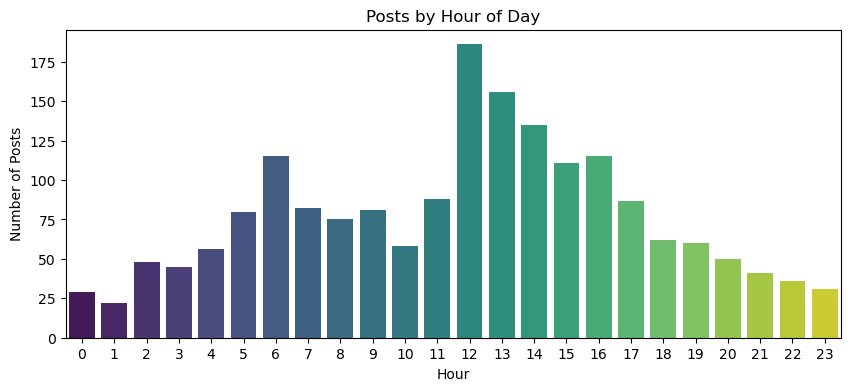

C:\Users\sugar\AppData\Local\Temp\ipykernel_9292\1968539791.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='day', data=df, order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'], palette='coolwarm')


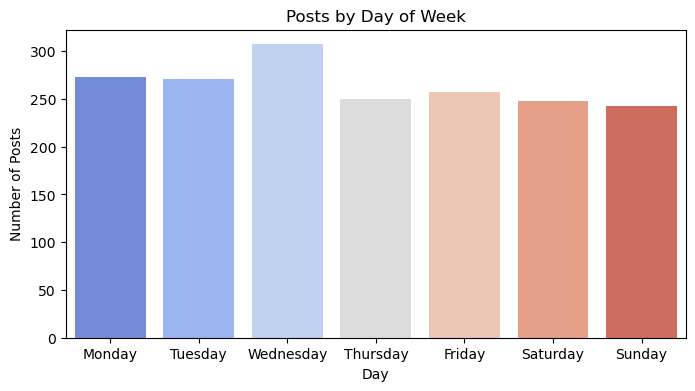

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert to datetime
df['publish_timestamp'] = pd.to_datetime(df['publish_timestamp'], errors='coerce')

# Extract post hour and day
df['hour'] = df['publish_timestamp'].dt.hour
df['day'] = df['publish_timestamp'].dt.day_name()

# Hourly posting pattern
plt.figure(figsize=(10, 4))
sns.countplot(x='hour', data=df, palette='viridis')
plt.title("Posts by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Posts")
plt.show()

# Daily pattern
plt.figure(figsize=(8, 4))
sns.countplot(x='day', data=df, order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'], palette='coolwarm')
plt.title("Posts by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Posts")
plt.show()

C:\Users\sugar\AppData\Local\Temp\ipykernel_9292\1981851955.py:20: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\sugar\.conda\envs\genaideepl\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


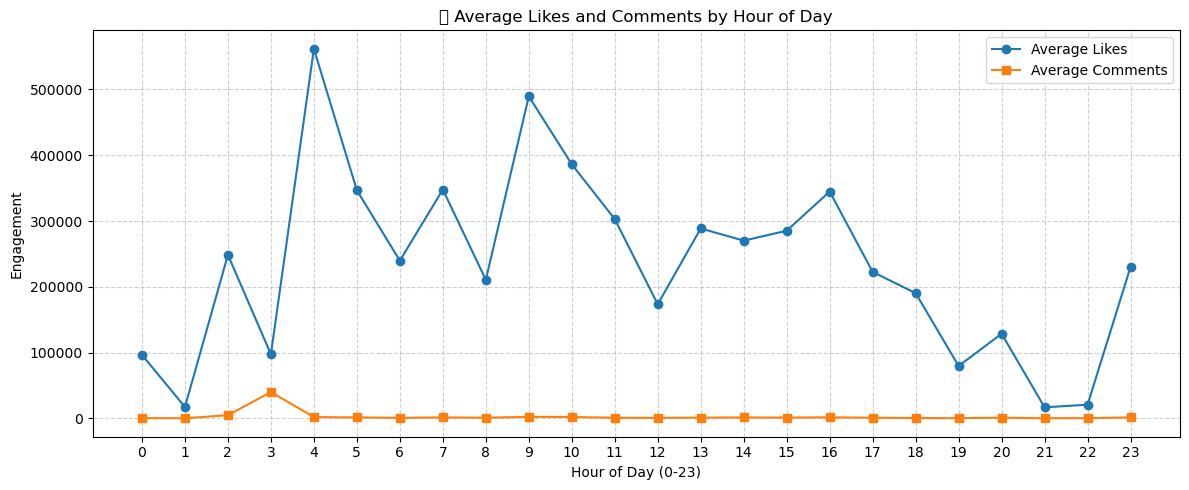

In [16]:


# Make sure timestamp is datetime
df['publish_timestamp'] = pd.to_datetime(df['publish_timestamp'], errors='coerce')

# Extract hour
df['hour'] = df['publish_timestamp'].dt.hour

# Group by hour
hourly_stats = df.groupby('hour')[['likes', 'comments']].mean()

# Plot
plt.figure(figsize=(12, 5))
hourly_stats['likes'].plot(label='Average Likes', marker='o')
hourly_stats['comments'].plot(label='Average Comments', marker='s')
plt.title('📈 Average Likes and Comments by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Engagement')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

C:\Users\sugar\AppData\Local\Temp\ipykernel_9292\4180805925.py:20: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\sugar\.conda\envs\genaideepl\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


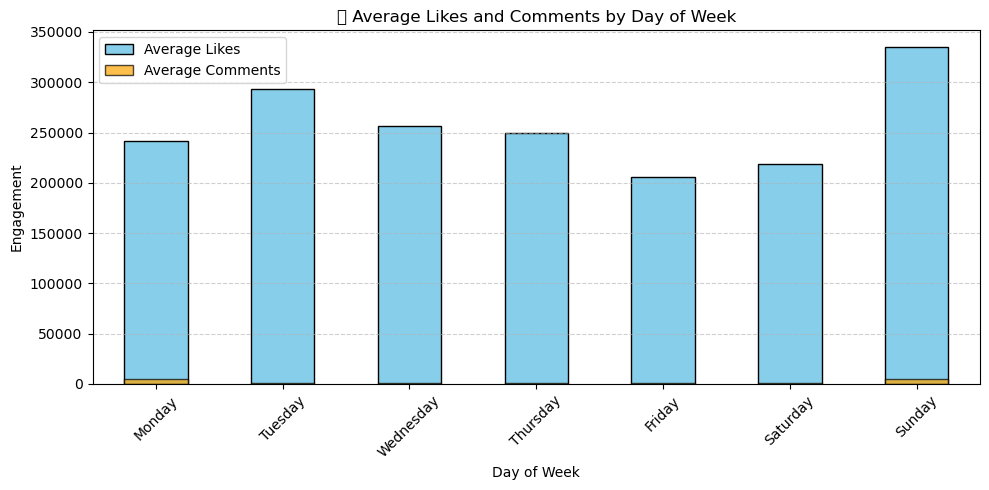

In [17]:
# Extract day of week
df['day'] = df['publish_timestamp'].dt.day_name()

# Set weekday order
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Group by day
daily_stats = df.groupby('day')[['likes', 'comments']].mean().reindex(days_order)

# Plot
plt.figure(figsize=(10, 5))
daily_stats['likes'].plot(kind='bar', color='skyblue', label='Average Likes', edgecolor='black')
daily_stats['comments'].plot(kind='bar', color='orange', label='Average Comments', edgecolor='black', alpha=0.7)
plt.title('📅 Average Likes and Comments by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Engagement')
plt.legend()
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Add time features based on timestamp

In [12]:
from datetime import datetime
import math

def extract_time_features(timestamp):
    dt = datetime.fromtimestamp(timestamp)

    hour = dt.hour
    weekday = dt.weekday()  # 0=Mon, 6=Sun

    hour_sin = math.sin(2 * math.pi * hour / 24)
    hour_cos = math.cos(2 * math.pi * hour / 24)

    weekday_sin = math.sin(2 * math.pi * weekday / 7)
    weekday_cos = math.cos(2 * math.pi * weekday / 7)

    return hour_sin, hour_cos, weekday_sin, weekday_cos

df[["hour_sin", "hour_cos", "weekday_sin", "weekday_cos"]] = (
    df["publish_timestamp"]
    .apply(lambda x: extract_time_features(x))
    .apply(pd.Series)
)


TypeError: 'str' object cannot be interpreted as an integer

### Class engagement rate into bins

In [ ]:

# Quantile-based classes
low = df["engagement_rate"].quantile(0.33)
high = df["engagement_rate"].quantile(0.66)

def label_engagement(x):
    if x <= low:
        return 0  # low
    elif x <= high:
        return 1  # medium
    else:
        return 2  # high

df["engagement_label"] = df["engagement_rate"].apply(label_engagement)
